# Analyse following simultaneously to find any pattern (in progress):  
1. Find synchronisation core

#### Progress:
- 1st node in main cluster enters at 175 timestep and large number of nodes starts entering  main cluster at around 3299. This justifies that why there is rise in global order initially but not visible while plotting node community matrix
- Print only if node entries changes

- Plot number of nodes entering with timestep
- Compare above plots
- On comparing by superimposing, nothing meaningful can be inferred
- Found probability
- Arrange probability matrix in terms of node communities

#### To do:
- Also try arranging by 'total effectiveness' ie darkest horizontal lines at top and lightest at bottom.
- 


In [1]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead 


from tes.analysis import AnalysisFunc

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm

import pandas as pd
import numpy as np


#### Create objects


In [2]:
reader=DataRead()

analyse=AnalysisFunc()

#### Load data

In [3]:
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
df_itr_1 = reader.data_read_bz2('raw/FN/itr_400.bz2')
# df_loc = reader.data_read_bz2('raw/test/loc_test.bz2')

df_nc = reader.data_read_bz2('raw/FN/nc_200.bz2')


#### Running analysis to get itration for analysis

In [ ]:
analyse.compute_param()

In [7]:
param=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


#### Superimposing plots at node count = 100 to see if there really exists a pattern

In [5]:
df_r=df_nc.reset_index(drop=True)

In [6]:
df_r.shape

(640000, 426)

#### Using node count function to compute node entering main cluster at times when this count changes

In [7]:
i=0
f=5000
time_list=[]
node_count_list=[]
while f < df_r.shape[0]:
    l=analyse.node_count(df_r.iloc[i:f,:])
    time_list.append(l['timestep'])
    node_count_list.append(l['node_count'])
    i=f
    f+=5000

In [8]:
nc_df=pd.DataFrame(node_count_list).T
nc_df

,0,1,2,3,4,5,6,7,8,9,...,117,118,119,120,121,122,123,124,125,126
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,77.0,1.0,2.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,79.0,2.0,1.0,1.0,1.0,1.0
2,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,80.0,1.0,1.0,1.0,1.0,1.0
3,4.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,...,1.0,1.0,1.0,1.0,81.0,1.0,1.0,1.0,1.0,1.0
4,5.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,2.0,82.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
time_df=pd.DataFrame(time_list).T
time_df

,0,1,2,3,4,5,6,7,8,9,...,117,118,119,120,121,122,123,124,125,126
0,0.0,33.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1187.0,0.0,0.0,0.0,0.0,239.0,0.0,113.0,0.0,1195.0
1,4.0,36.0,53.0,31.0,2.0,8.0,5.0,48.0,15.0,12.0,...,1188.0,5.0,4.0,374.0,1.0,240.0,2.0,116.0,8.0,1199.0
2,5.0,42.0,74.0,54.0,9.0,9.0,11.0,74.0,24.0,19.0,...,1193.0,27.0,5.0,385.0,3.0,256.0,85.0,117.0,17.0,1208.0
3,13.0,46.0,79.0,57.0,11.0,11.0,16.0,84.0,58.0,20.0,...,1263.0,72.0,11.0,388.0,5.0,257.0,93.0,118.0,19.0,1255.0
4,25.0,50.0,81.0,76.0,12.0,170.0,19.0,86.0,68.0,26.0,...,1272.0,96.0,13.0,401.0,7.0,262.0,115.0,125.0,28.0,1375.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Plot node count entering at every timestep

Text(0.5, 1.0, 'Main cluster formation during transition')

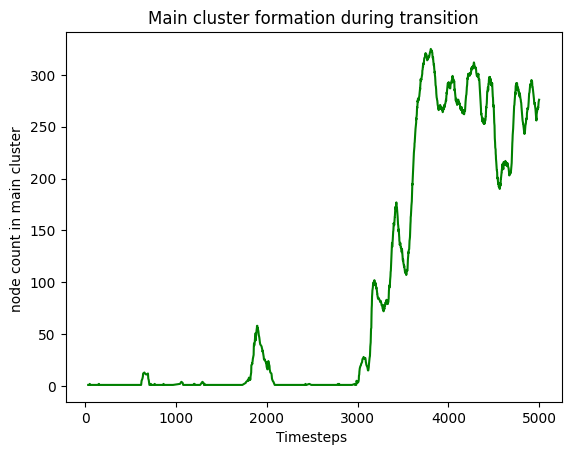

In [14]:
#plt.plot(time_df[0],nc_df[0],color='r')
plt.plot(time_df[1],nc_df[1],color='g')
plt.xlabel('Timesteps ')
# plt.xlabel('Timesteps at which node count or node number changes')
plt.ylabel('node count in main cluster ')
plt.title('Main cluster formation during transition')

We can also plot node count only above.

Text(0.5, 1.0, 'node count in. main cluster')

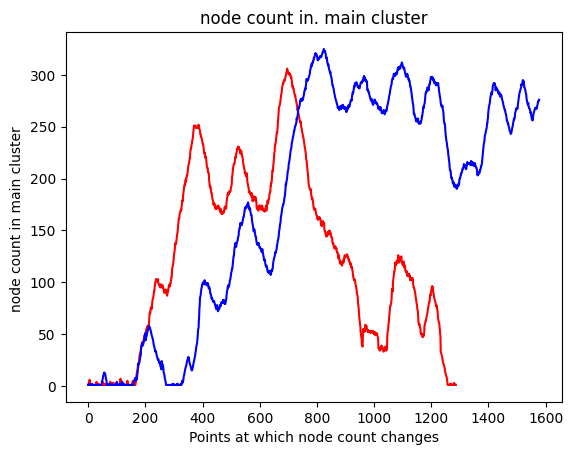

In [11]:

plt.plot(range(0,nc_df[0].shape[0]),nc_df[0],color='r')
plt.plot(range(0,nc_df[1].shape[0]),nc_df[1],color='b')
plt.xlabel('Points at which node count changes')
plt.ylabel('node count in main cluster ')
plt.title('node count in. main cluster')

#### Define the function for overlapping

In [9]:
def plot_nc_overlap(nc_df,name):
    df_check=nc_df.apply(lambda c: c>=100)
    
    set_point = 500
    c=0
    for i in range(0,df_check.shape[1]):
        for val in df_check[i]:
            
            c+=1
            if val == True:
                ts=c
                c=0
                break
        x=list(range(0,nc_df[i].shape[0]))
        
        if ts-1>set_point:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            
            plt.plot(x,nc_df[i].shift(-(ts-set_point)),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        else:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            plt.plot(x,nc_df[i].shift(set_point-ts),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        i+=1
    
    plt.xlabel("timestep")
    plt.ylabel("Node count")
    plt.title(name)
#plt.savefig('../../data/results/PIR_node_count.png')

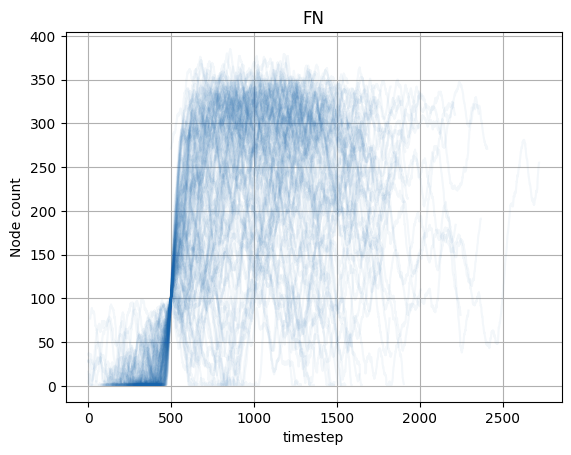

In [11]:
plot_nc_overlap(nc_df,'FN')

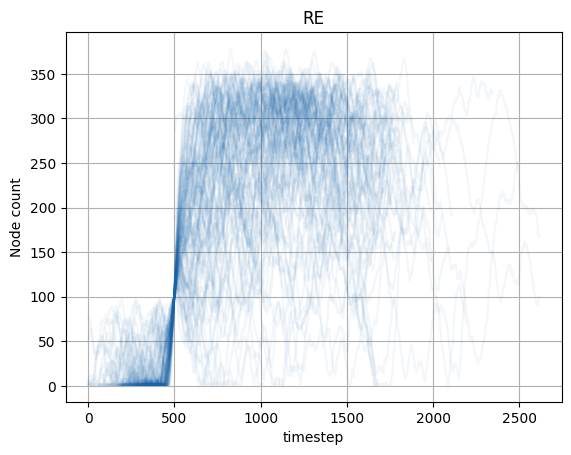

In [20]:
plot_nc_overlap(nc_df,'RE')

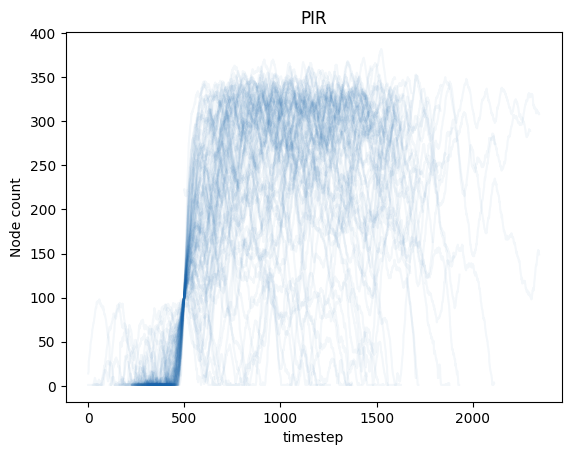

In [31]:
plot_nc_overlap(nc_df,'PIR')

From above, nothing meaningful after overlapping signals

In [8]:
#let's see if node list is calculated how
#df_nc.loc[2]
nl=analyse.node_count(df_nc.loc[2])
node_list=nl['node_list']


In [6]:
nl.keys()

dict_keys(['node_count', 'timestep', 'node_list'])

In [1]:
len(node_list)

NameError: name 'node_list' is not defined

# Algorithm to find probability of nodes pulling other nodes

In [11]:
# defining test case to check for algorithm
test_list=[[1],[1, 2], [1,4,3],[2,5],[1,2,3]]
print(test_list)


test_list=[[1],[1, 2], [1,4,3],[2,5],[1,2,3]]

[[1], [1, 2], [1, 4, 3], [2, 5], [1, 2, 3]]


#### Defining it as a function for calculating probability

In [21]:
def prob_matrix(node_list):
    # defining network nodes list
    network_nodes = list(range(1, 427))
    comp_list=network_nodes
    
    # use node_count function to extract node lists
    # nl=analyse.node_count(df_nc.loc[2])
    # node_list=nl['node_list']
    num_matrix = np.zeros((426,426))
    den_matrix = np.zeros((426,426))
    test_list=node_list
    
    for n in network_nodes:
        
        #comp_list=temp_nodes
        #print(temp_nodes)
        #print(len(temp_nodes))
        comp_list.remove(n)
            
        for m in comp_list:
            
            for id, case in enumerate(test_list):
                if n in case and m not in case:
                    if id+1 != len(test_list):
                        if n in test_list[id+1] and m in test_list[id+1]:
                            num_matrix[n-1, m-1]+=1
                            den_matrix[n-1,m-1]+=1
                        else:
                            den_matrix[n-1,m-1]+=1
                    else:
                        break
                else:
                    continue
    
        comp_list=list(range(1,427))
    
    
    prob_matrix=np.divide(num_matrix,den_matrix)
    # print(num_matrix)
    # print(den_matrix)
    # print(prob_matrix)
    # arranging prob matrix nodes in order of mb communities
    comm=reader.get_communities()
    # desired_order = list(comm.index)
    # reordered_mat=prob_matrix[desired_order,:]
    # final_mat=reordered_mat[:,desired_order]
    return prob_matrix
    
                    
                
        
        
        


## Averaging probability matrices for nc data of FN (for 200 iterations)


In [84]:
df_r=df_nc.reset_index(drop=True)

In [ ]:
i=0
f=5000
p_mat_stack=[]
while f < df_r.shape[0]:
    # finding node list for given nc data
    l=analyse.node_count(df_r.iloc[i:f,:])
    # calculating probability matrix for above node list
    p_mat = prob_matrix(l['node_list'])
    p_mat=list(p_mat)
    p_mat_stack.append(p_mat)
  
    
    i=f
    f+=5000


mat_stack=np.stack(p_mat_stack,axis=0)
mat_avg=np.nanmean(mat_stack,axis=0)
    
np.save("../../data/raw/prob_avg",mat_avg)

In [4]:
prob_avg_mat=np.load("../../data/raw/prob_avg.npy")
prob_avg_mat.shape

(426, 426)

/tmp/ipykernel_79180/4240745689.py:1: RuntimeWarning: divide by zero encountered in log
  ax=plt.imshow(np.log(prob_avg_mat),cmap='RdBu')


Text(0, 0.5, 'Puller nodes')

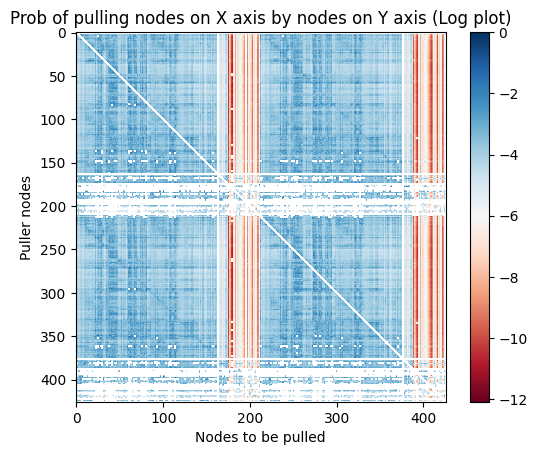

In [19]:
ax=plt.imshow(np.log(prob_avg_mat),cmap='RdBu')
plt.colorbar(ax)
plt.title('Prob of pulling nodes on X axis by nodes on Y axis (Log plot)')
plt.xlabel('Nodes to be pulled')
plt.ylabel('Puller nodes')

#### Arranging nodes in order of MB communities

/tmp/ipykernel_106021/3197544485.py:10: RuntimeWarning: divide by zero encountered in log
  axs=ax.imshow(np.log(final_mat),cmap='RdBu')


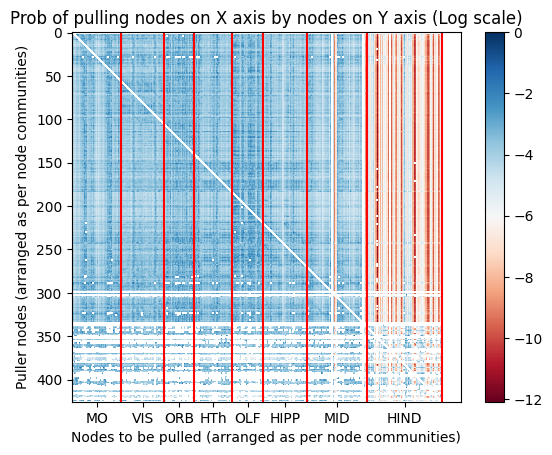

In [9]:
comm=reader.get_communities()
desired_order = comm['des_order']
reordered_mat=prob_avg_mat[desired_order,:]
final_mat=reordered_mat[:,desired_order]

# community divider lines 
com_div = np.cumsum(comm['comm_val'])

fig,ax=plt.subplots()
axs=ax.imshow(np.log(final_mat),cmap='RdBu')
fig.colorbar(axs)
for i in com_div:
    ax.axvline(i,color='r')
ax.set_xticks(com_div-comm['comm_val']/2)
ax.set_xticklabels(comm['name_seq'])
plt.title('Prob of pulling nodes on X axis by nodes on Y axis (Log scale)')
plt.xlabel('Nodes to be pulled (arranged as per node communities)')
plt.ylabel('Puller nodes (arranged as per node communities)')
plt.show()

# Trying to arrange darkest lines on the top


/tmp/ipykernel_106021/1657740091.py:9: RuntimeWarning: divide by zero encountered in log
  log_mat = np.log(final_mat)


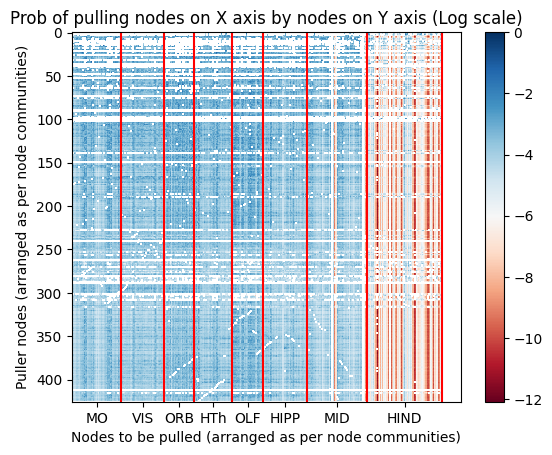

In [41]:
comm=reader.get_communities()
desired_order = comm['des_order']
reordered_mat=prob_avg_mat[desired_order,:]
final_mat=reordered_mat[:,desired_order]

# defining list to store count values
count=[]
# converting matrix to log matrix
log_mat = np.log(final_mat)
for i in range(0,final_mat.shape[0]):
    count_row=np.sum((log_mat[i,:]<=0) & (log_mat[i,:]>=-2
                                         ))
    count.append(count_row)

# argsort count 
count=np.array(count)
ind=count.argsort()
# desired order of rows from darkest rows to lightest rows
des_order=ind[::-1]

final_mat=log_mat[des_order,:]

# community divider lines 
com_div = np.cumsum(comm['comm_val'])

fig,ax=plt.subplots()
axs=ax.imshow(final_mat,cmap='RdBu')
fig.colorbar(axs)
for i in com_div:
    ax.axvline(i,color='r')
ax.set_xticks(com_div-comm['comm_val']/2)
ax.set_xticklabels(comm['name_seq'])
plt.title('Prob of pulling nodes on X axis by nodes on Y axis (Log scale)')
plt.xlabel('Nodes to be pulled (arranged as per node communities)')
plt.ylabel('Puller nodes (arranged as per node communities)')
plt.show()

In [44]:
count[ind] 




array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [45]:
ind


array([425, 146, 147, 306, 149, 305, 152, 153, 154, 155, 304, 158, 159,
       299, 161, 297, 164, 165, 166, 167, 168, 169, 171, 173, 145, 174,
       144, 307, 112, 322, 320, 116, 117, 118, 119, 245, 316, 122, 123,
       315, 314, 129, 130, 310, 134, 135, 309, 308, 138, 139, 140, 143,
       175, 176, 294, 213, 214, 215, 216, 272, 270, 220, 221, 222, 261,
       224, 225, 227, 228, 229, 255, 254, 253, 234, 235, 249, 248, 246,
       273, 211, 209, 208, 291, 180, 287, 182, 285, 184, 185, 284, 187,
       188, 280, 111, 190, 279, 193, 195, 196, 198, 278, 202, 203, 205,
       206, 274, 191, 109, 319, 371, 387, 384, 382,  38,  41,  42,  43,
       378, 377, 376,  48,  49, 375, 374, 372,  53,  54, 329,  56,  58,
        59,  60,  62,  34,  63,  33, 391,   1, 421, 420, 419,   6, 418,
       417, 415,  10,  11,  13,  14, 414,  17, 412,  19,  20,  21, 408,
       403, 402, 397, 396, 389, 369, 244, 366, 353,  81, 100,  99,  83,
       339,  97,  85, 348,  96,  87,  88, 341, 346,  94, 344,  9

In [38]:
des_order[0:50]

array([395, 406, 357, 398, 413, 355, 363, 386, 349, 409, 364, 361, 351,
       385, 282, 281, 302, 350, 323, 416, 368, 411,  18, 288, 343, 401,
       410, 317, 324, 345, 379, 256, 407, 230, 250, 262,  26, 223, 219,
       263,  98, 325,   0, 289, 201, 394, 392, 422, 388, 404])

In [27]:
count=np.array(count)
ind=count.argsort()
des_order=ind[::-1]

array([406, 395, 357, 416, 288, 413, 411, 281, 256, 394, 323, 401, 407,
       350, 392, 351, 422, 363, 364, 355, 136, 131, 132, 133, 147, 134,
       135, 137, 143, 138, 146, 145, 139, 140, 141, 129, 144, 142, 130,
       425, 128, 127, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       148, 152, 149, 176, 178, 179, 180, 181, 182, 183, 184, 185, 186,
       187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,
       200, 177, 175, 150, 174, 151, 102, 153, 154, 155, 156, 157, 158,
       159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171,
       172, 173, 103,  93, 101,  37,  27,  28,  29,  30,  31,  32,  33,
        34,  35,  36,  38,  25,  39,  40,  41,  42,  43,  44,  45,  46,
        47,  48,  26,  24, 100,  11,   1,   2,   3,   4,   5,   6,   7,
         8,   9,  10,  12,  23,  13,  14,  15,  16,  17,  18,  19,  20,
        21,  22,  49,  50,  51,  88,  78,  79,  80,  81,  82,  8

In [25]:
count

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [26]:
count[406]

3

In [21]:
np.unique(count)

array([0, 1, 2, 3])

AttributeError: module 'numpy' has no attribute 'count'

In [ ]:


peek_prob(prob_avg_mat)

In [60]:
#peek_prob(mat_avg)
mat_avg.shape
len(p_mat_stack)
#p_mat_stack

mat_stack.shape
mat_avg.shape


(426, 426)

In [39]:
# code for averaging arrays

a=np.array([[1,2],[3,4]])
b=np.array([[3,6],[3,6]])
r=[]
a=list(a)
b=list(b)
r.append(a)
r.append(b)
f_mat=np.stack(r,axis=0)
print(f_mat)
f_avg=np.nanmean(f_mat,axis=0)
print(f_avg)


[[[1 2]
  [3 4]]

 [[3 6]
  [3 6]]]
[[2. 4.]
 [3. 5.]]


In [38]:
f_avg=np.nanmean(f_mat,axis=0)
f_avg

array([[2., 4.],
       [3., 5.]])

In [34]:
f_avg.shape

(2, 2)

In [ ]:
analyse.computeparam()

In [5]:
nl3=analyse.node_count(df_nc.loc[3])
l3=nl3['node_list']
p3=prob_matrix(l3)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[ 0.  0. 37. ... 64. 64. 64.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [23. 23.  0. ... 50. 50. 50.]
 ...
 [28. 28. 28. ...  0. 28. 28.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]]
[[       nan        nan 0.02702703 ... 0.         0.         0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.         0.                nan ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ...        nan 0.         0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]


/tmp/ipykernel_58307/3315779407.py:37: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


In [6]:
nl7=analyse.node_count(df_nc.loc[7])
l7=nl7['node_list']
p7=prob_matrix(l7)

[[0. 0. 3. ... 1. 5. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 1. 3. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [2. 0. 1. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[  0.   0. 198. ... 341. 182. 366.]
 [  0.   0.   0. ...   0.   0.   0.]
 [ 30.  18.   0. ... 174.  96. 198.]
 ...
 [  0.   0.   1. ...   0.   2.  25.]
 [ 79.   0. 161. ... 240.   0. 263.]
 [  0.   0.   0. ...   0.   0.   0.]]
[[       nan        nan 0.01515152 ... 0.00293255 0.02747253 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.03333333 0.                nan ... 0.00574713 0.03125    0.        ]
 ...
 [       nan        nan 0.         ...        nan 0.         0.        ]
 [0.02531646        nan 0.00621118 ... 0.00416667        nan 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]]


/tmp/ipykernel_58307/3315779407.py:37: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


In [7]:
nl10=analyse.node_count(df_nc.loc[10])
l10=nl10['node_list']
p10=prob_matrix(l10)

[[0. 0. 5. ... 0. 4. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [3. 1. 0. ... 0. 3. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[  0.   0. 134. ... 560. 418. 560.]
 [  0.   0.   0. ...   0.   0.   0.]
 [120.  31.   0. ... 546. 393. 546.]
 ...
 [  0.   0.   0. ...   0.   0.   0.]
 [ 25.   0.  14. ... 167.   0. 167.]
 [  0.   0.   0. ...   0.   0.   0.]]
[[       nan        nan 0.03731343 ... 0.         0.00956938 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]
 [0.025      0.03225806        nan ... 0.         0.00763359 0.        ]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [0.04              nan 0.07142857 ... 0.                nan 0.        ]
 [       nan        nan        nan ...        nan        nan        nan]]


/tmp/ipykernel_58307/3315779407.py:37: RuntimeWarning: invalid value encountered in divide
  prob_matrix=np.divide(num_matrix,den_matrix)


/tmp/ipykernel_58307/1804635443.py:2: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p3),cmap='RdBu')


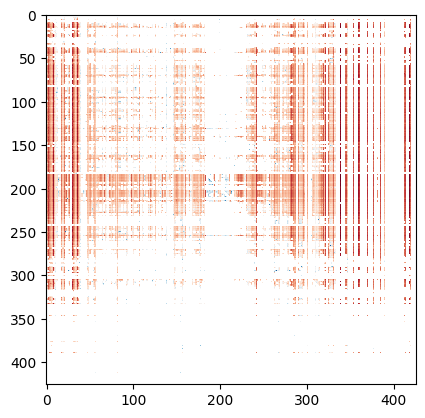

In [12]:
#plot
plt.imshow(np.log(p3),cmap='RdBu')

/tmp/ipykernel_58307/246713654.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p7),cmap='RdBu')


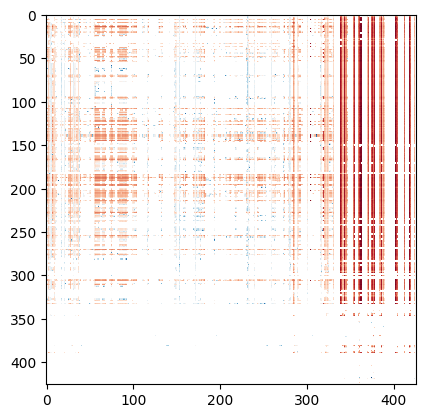

In [13]:
plt.imshow(np.log(p7),cmap='RdBu')

/tmp/ipykernel_58307/3015521285.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p10),cmap='RdBu')


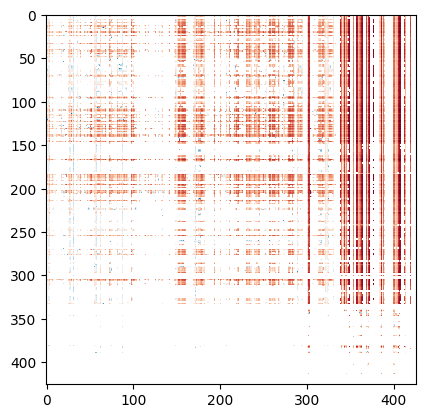

In [14]:
plt.imshow(np.log(p10),cmap='RdBu')

In [22]:
p3[idx].shape
p3[:,idx][idx]


array([[       nan, 0.        , 0.        , ...,        nan,        nan,
        0.        ],
       [0.00917431,        nan, 0.        , ...,        nan,        nan,
        0.        ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.0008643 , 0.00280636, 0.        , ...,        nan, 0.0078125 ,
        0.        ],
       [0.00110988, 0.00369004, 0.        , ...,        nan,        nan,
        0.        ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])

/tmp/ipykernel_58307/4095717263.py:2: RuntimeWarning: Mean of empty slice
  idx=np.nanmean(p3,axis=1).argsort()
/tmp/ipykernel_58307/4095717263.py:3: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p3[:,idx][idx]),cmap='RdBu')


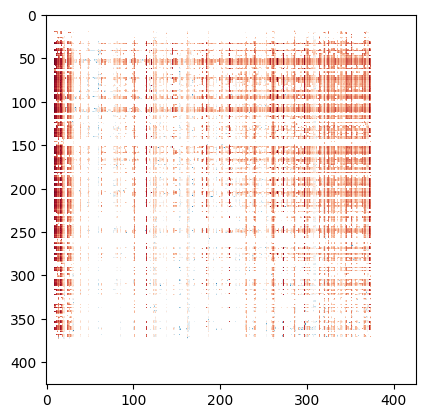

In [25]:
p3[p3==np.nan]=0
idx=np.nanmean(p3,axis=1).argsort()
plt.imshow(np.log(p3[:,idx][idx]),cmap='RdBu')

In [ ]:
#checking new algo

In [96]:
nc_t=np.array([1,0,0,1,0],dtype='bool')
nc_t1=np.array([1,1,0,1,0],dtype='bool')

M1=np.outer(nc_t,~nc_t)
M2=np.outer(nc_t1,nc_t1)
M3=np.outer(nc_t1,~nc_t1)
M4=np.outer(~nc_t1,nc_t1)

num=M1*M2
den=M1*(M2+M3+M4)
prob=num/den
print(prob)

[[nan  1.  0. nan  0.]
 [nan nan nan nan nan]
 [nan nan nan nan nan]
 [nan  1.  0. nan  0.]
 [nan nan nan nan nan]]


/tmp/ipykernel_79180/3504774950.py:11: RuntimeWarning: invalid value encountered in divide
  prob=num/den


## Vectorize above algo

In [85]:
def prob_mat_sir(df_nc):
    nc=np.array(df_nc)
    mc = analyse.compute_main_cluster(df_nc)
    nc=nc==mc
    num=np.zeros((nc.shape[1],nc.shape[1]))
    den=np.zeros((nc.shape[1],nc.shape[1]))
    for i in range(nc.shape[0]-1):
        nc_t=nc[i,:]
        nc_t1=nc[i+1,:]
        M1=np.outer(nc_t,~nc_t)
        M2=np.outer(nc_t1,nc_t1)
        M3=np.outer(nc_t1,~nc_t1)
        M4=np.outer(~nc_t1,nc_t1)
        num+=M1*M2
        den+=M1*(M2+M3+M4)
       
    prob=num/den
    return(prob)
    

## Applying vector algo to whole node community data of 128 transitions in FN

In [90]:
i=0
f=5000
p_mat_stack=[]
while f < df_r.shape[0]:
    # finding node list for given nc data
    l=df_r.iloc[i:f,:]
    # calculating probability matrix for above node list
    p_mat = prob_mat_sir(l)
    p_mat=list(p_mat)
    p_mat_stack.append(p_mat)
  
    
    i=f
    f+=5000


mat_stack=np.stack(p_mat_stack,axis=0)
mat_avg=np.nanmean(mat_stack,axis=0)
    
np.save("../../data/raw/prob_avg_sir",mat_avg)

/tmp/ipykernel_79180/3344392854.py:17: RuntimeWarning: invalid value encountered in divide
  prob=num/den
/tmp/ipykernel_79180/3510327955.py:18: RuntimeWarning: Mean of empty slice
  mat_avg=np.nanmean(mat_stack,axis=0)


In [91]:
mat_stack.shape

(127, 426, 426)

/tmp/ipykernel_79180/2110773453.py:10: RuntimeWarning: divide by zero encountered in log
  axs=ax.imshow(np.log(final_mat),cmap='RdBu')


Text(0, 0.5, 'Puller nodes (arranged as per node communities)')

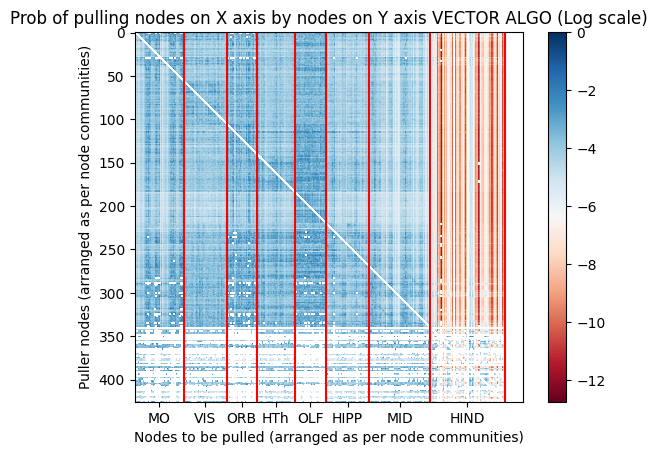

In [94]:
comm=reader.get_communities()
desired_order = comm['des_order']
reordered_mat=mat_avg[desired_order,:]
final_mat=reordered_mat[:,desired_order]
# community divider lines 
com_div = np.cumsum(comm['comm_val'])


fig,ax=plt.subplots()
axs=ax.imshow(np.log(final_mat),cmap='RdBu')
fig.colorbar(axs)
for i in com_div:
    ax.axvline(i,color='r')
ax.set_xticks(com_div-comm['comm_val']/2)
ax.set_xticklabels(comm['name_seq'])
plt.title('Prob of pulling nodes on X axis by nodes on Y axis VECTOR ALGO (Log scale)')
plt.xlabel('Nodes to be pulled (arranged as per node communities)')
plt.ylabel('Puller nodes (arranged as per node communities)')

In [93]:
peek_prob(mat_avg)

The length of array for prob 1.0 is 20
The length of array for prob 0.7333333333333334 is 2
The length  of array for prob 0.6666666666666666 is 1
The length of array for prob 0.5625 is 3


{'p1': [array([137,  26]),
  array([149,  36]),
  array([149,  92]),
  array([179, 227]),
  array([180, 391]),
  array([184, 238]),
  array([187, 116]),
  array([194,  57]),
  array([297,  62]),
  array([362, 292]),
  array([363, 307]),
  array([391, 146]),
  array([393, 142]),
  array([394, 140]),
  array([401,  42]),
  array([406, 215]),
  array([406, 330]),
  array([411, 288]),
  array([417, 153]),
  array([417, 289])],
 'p2': [array([413, 292]), array([413, 328])],
 'p3': [array([401, 371])],
 'p4': [array([272,  62]), array([297,  81]), array([407, 335])]}

/tmp/ipykernel_58307/3570198630.py:5: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(final_mat),cmap='RdBu')


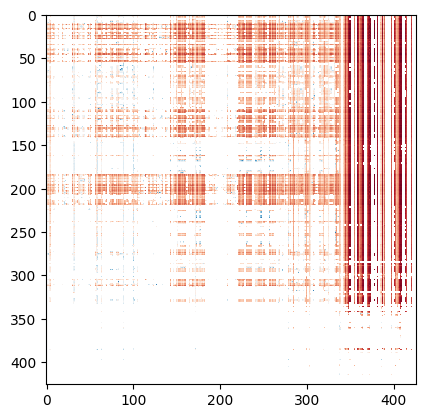

In [45]:
comm=reader.get_communities()
desired_order = list(comm.index)
reordered_mat=prob[desired_order,:]
final_mat=reordered_mat[:,desired_order]
plt.imshow(np.log(final_mat),cmap='RdBu')


/tmp/ipykernel_58307/3015521285.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(p10),cmap='RdBu')


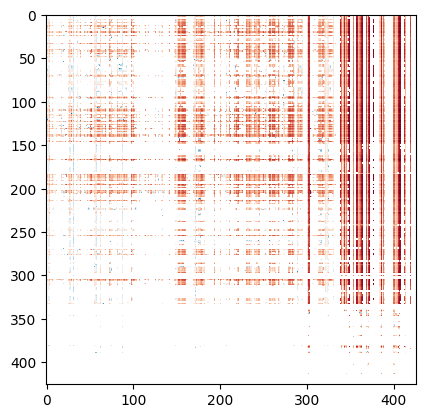

In [46]:
plt.imshow(np.log(p10),cmap='RdBu')

In [34]:
nc_t

array([-2, -1, -1, -2, -1])

In [8]:
#defining function to peek inside probablility mprob_matrix
def peek_prob(p):
    l=np.unique(p)
    ls=np.sort(l,axis=None)
    # calculating prob values 
    p_val=ls[::-1][1:10]

    ind_max=np.argwhere(p==p_val[0])
    i1=list(ind_max)
    ind_2max=np.argwhere(p==p_val[1])
    i2=list(ind_2max)
    ind_3max=np.argwhere(p==p_val[2])
    i3=list(ind_3max)
    ind_4max=np.argwhere(p==p_val[3])
    i4=list(ind_4max)

    print(f'The length of array for prob {p_val[0]} is {len(ind_max)}')
    print(f'The length of array for prob {p_val[1]} is {len(ind_2max)}')
    print(f'The length  of array for prob {p_val[2]} is {len(ind_3max)}')
    print(f'The length of array for prob {p_val[3]} is {len(ind_4max)}')

    values=[i1,i2,i3,i4]
    keys=['p1','p2','p3','p4']
    node_pair_dict = dict(zip(keys,values))
    return node_pair_dict

In [ ]:
# take final matrix as avg for all iterations

In [73]:
peek3=peek_prob(p3)

The length of array for prob 1.0 is 185
The length of array for prob 0.6666666666666666 is 5
The length  of array for prob 0.5 is 236
The length of array for prob 0.4 is 13


In [74]:
peek7 = peek_prob(p7)

The length of array for prob 1.0 is 410
The length of array for prob 0.6666666666666666 is 4
The length  of array for prob 0.5 is 408
The length of array for prob 0.4 is 13


In [77]:
peek10=peek_prob(p10)

The length of array for prob 1.0 is 347
The length of array for prob 0.6666666666666666 is 3
The length  of array for prob 0.5 is 311
The length of array for prob 0.4 is 9


Let's check the pairs having probaability 1

In [ ]:
# extracting 1st element of each list pair
list_1ind = []
i=0
while i < len(peek3['p1']):
    list_1ind.append(peek3['p1'][i][0])
    i+=1

print(list_1ind)

u, count = np.unique(list_1ind, return_counts=True)
#print(f'unique vaalues {u}')
#print(f'counts of unique values {count}')

count_dict = dict(zip(u, count)) 

dict(sorted(count_dict.items(), key=lambda item: item[1]))




In [ ]:
# extracting 1st element of each list pair
list_1ind = []
i=0
while i < len(peek6['p1']):
    list_1ind.append(peek6['p1'][i][0])
    i+=1

print(list_1ind)

u, count = np.unique(list_1ind, return_counts=True)


#print(f'unique vaalues {u}')
#print(f'counts of unique values {count}')

count_dict = dict(zip(u, count)) 
dict(sorted(count_dict.items(), key=lambda item: item[1]))

#print(count_dict)



In [ ]:
# extracting 1st element of each list pair
list_1ind = []
i=0
while i < len(peek10['p1']):
    list_1ind.append(peek10['p1'][i][0])
    i+=1

print(list_1ind)

u, count = np.unique(list_1ind, return_counts=True)


#print(f'unique vaalues {u}')
#print(f'counts of unique values {count}')

count_dict = dict(zip(u, count)) 
dict(sorted(count_dict.items(), key=lambda item: item[1]))

#print(count_dict)

